## Домашнее задание 3 (10 баллов)

## НИУ ВШЭ, 2024-25 учебный год

## Формат сдачи

Сам ноутбук называйте в формате hw-03-USERNAME.ipynb, где USERNAME — ваши фамилия и имя. Файл надо будет сдать в anytask.

## О задании

В этом домашнем задании вы получите опыт подготовки данных и EDA (Exploratory Data Analysis), приблизившись к реальной работе с данными с помощью уже знакомых вам инструментов: numpy, pandas, matplotlib и seaborn, а также познакомитесь с plotly.

EDA - важный этап работы с данными. Именно в процессе EDA вы можете выяснить особенности датасета, найти зависимости в данных, протестировать гипотезы о взаимосвязях признаков и целевой переменной. В реальности вы сами будете определять, что и как проверять в рамках EDA, однако в данной работе гипотезы будут выдвинуты за вас автором задания. Также и типы графиков, которые вы будете использовать уже предопределены за вас. Выполняя задания по визуализациям, обращайте внимание на референсные картинки, которые были оставлены авторами. Они показывают, какой примерно результат от вас ожидается.

Это задание будет включать в себя построение некоторого количества графиков, потому вот основные правила, в соответствии с которыми графики должны быть оформлены:
1. Любой график всегда имеет название.
2. Оси у графика подписаны (исключение - график делит название оси с соседним).
3. Подписи делаются на одном языке (либо английский, либо русский), но не на их смеси.
4. Если вы выводите несколько графиков, то они размещаются в рамках одного объекта matplotlib.pyplot.figure. Вы не выводите графики последовательно, а смотрите, как их разместить сразу все за раз.
5. Отдельные графики (если графиков на картинке больше 1) также имеют свои названия.
6. Если на графике есть несколько различных объектов, то для их различения используется легенда. Помещайте легенду в место, где она в наименьшей мере мешает восприятию самого графика.
7. Если есть легенда, то она должна иметь навание, а также ее содержание должно быть адекватными (пожалейте проверяющих, они не хотят разбирать, а к чему относится зеленая линия, которая на легенде помечена меткой "0").
8. Используйте цветовые гаммы, чтобы объекты на графиках отличались цветом.
9. Текст на визуализации должен быть читаем. Если вы вывели названия категорий в качестве подписей на оси Х, а эти названия наезжают друг на друга, то вам нужно что-то с этим сделать. Нечитаемый или плохо читаемый (очень маленький, невероятно огромный) текст ведет к снижению баллов.

При работе с табличными данными используйте функционал [style](https://pandas.pydata.org/docs/user_guide/style.html#Builtin-Styles), чтобы визуально выделять необходимые элементы.

В этом задании будут оцениваться ваши развернутые комментарии, размышления и выводы (по построенным графикам): не скупитесь на них, но следите, чтобы выводы не были поверхностными и очевидными.

*Тут правило про плагиат, которое вам итак известно - обнуляются все работы, которые подозреваются в некорректных заимствованиях!* Помните, что просто скопировать код из интернета и указать источник - это не ваша самостоятельная работа, а автора кода. Измените хоть что-нибудь в коде.

## О данных

Будем работать с [датасетом физической активности](https://www.kaggle.com/datasets/uciml/human-activity-recognition-with-smartphones).

В этом датасете собраны данные 30 человек, выполняющих различные действия со смартфоном на поясе. Данные записывались с помощью датчиков (акселерометра и гироскопа) в этом смартфоне. Были зафиксированы: "3-осевое линейное ускорение" (_tAcc-XYZ_) и "3-осевая угловая скорость" (_tGyro-XYZ_).

1. Все сигналы отсортированы по времени, пропущены через фильтр шума.
2. Все наблюдения были разделены на окна по 128 сигналов в каждом, причем окна пересекаются на 50% (грубо говоря, с 1 по 128 сигнал в 1 окно, с 64 до 192 сигнала - во 2 окно и так далее). То есть каждое окно покрывает 2.56 секунды данных (два шага человека при ходьбе, учитывая медленную походку пожилых людей).
3. Линейное ускорение было разделено на две составляющие (с помощью низкочастотного фильтра): ускорение самого тела, а также гравитационная составляющая. Будем называть их ускорением тела и гравитационным ускорением.
4. К получившимся окнам применяли различные функции для получения следующих показателей:
    - max
    - min
    - mad (median)
    - mean
    - std
    - skewness (коэффициент асимметричности распределения признака в окне)
    - etc. (подробнее, на сколько это возможно, указано в [самой статье](https://www.esann.org/sites/default/files/proceedings/legacy/es2013-84.pdf))
5. Величина (magnitude) сигнала также определялась через евклидову норму всех значений из вектора для одного окна.
6. К окнам было применено преобразование Фурье, чтобы получить частоты. Из частот были извелченыте же показатели, плюс новые:
    - bandsEnergy (энергия частотного интервала)
7. Были посчитаны углы между векторами соответствующих окон.
8. Для ускорений были посчитаны производные - рывки, к которым применялись те же функции.

Итог: в датасете каждый признак - это какая-то операция над вектором из 128 чисел, которые соответствуют замерам определенного человека занятого какой-то активностью на протяжении 2.56 секунд.

Как читать названия признаков? Примеры:
- `tBodyAccMag-mean()` - это вектор ускорений тела (без гравитационной составляющей этого ускорения), из которого взяли евклидову норму, а затем усреднили, чтобы получить скаляр
- `fBodyAcc-bandsEnergy()-1,8.2` - это вектор ускорения тела, к которому применили преобразование Фурье, преобразовав его в вектор частот, а затем посчитали на этом векторе энергию данного частотного интервала в определенном диапазоне частот (в данном случае 1 - 8.2)
- `angle(X,gravityMean)` - это угол между осью Х и вектором усредненных значений гравитационного ускорения из соответствующего окна

Вероятно, сначала покажется сложным, но мы разберемся с некоторыми признаками в отдельности и вы сможете понять их смысл, уже исходя из фактических соотношений.

## Предобработка данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [2]:
train = pd.read_csv('train.csv')
test = pd.read_csv("test.csv")

In [3]:
train.columns

Index(['tBodyAcc-mean()-X', 'tBodyAcc-mean()-Y', 'tBodyAcc-mean()-Z',
       'tBodyAcc-std()-X', 'tBodyAcc-std()-Y', 'tBodyAcc-std()-Z',
       'tBodyAcc-mad()-X', 'tBodyAcc-mad()-Y', 'tBodyAcc-mad()-Z',
       'tBodyAcc-max()-X',
       ...
       'fBodyBodyGyroJerkMag-kurtosis()', 'angle(tBodyAccMean,gravity)',
       'angle(tBodyAccJerkMean),gravityMean)',
       'angle(tBodyGyroMean,gravityMean)',
       'angle(tBodyGyroJerkMean,gravityMean)', 'angle(X,gravityMean)',
       'angle(Y,gravityMean)', 'angle(Z,gravityMean)', 'subject', 'Activity'],
      dtype='object', length=563)

In [4]:
train.shape

(7352, 563)

В датасете 563 признака, включая целевую переменную. Столько признаков нам не нужно. Мы за вас сделали подвыборку признаков для удобства работы с ними.

In [5]:
cols_subset = [
    'tBodyAccMag-mean()',  # усредненная величина ускорения тела
    'tBodyGyroJerk-mad()-X',  # медианная величина рывка тела по оси Х
    'tGravityAcc-min()-X',  # минимум гравитационной составляющей ускорения по оси Х
    'tBodyAcc-max()-X',  # максимальная величина ускорения тела по оси Х
    'fBodyAcc-bandsEnergy()-1,8.2',  # энергия ускорения тела в интервале частоты
    'angle(X,gravityMean)',  # угол между осью Х и усредненной гравитационной составляющей ускорения
    'angle(Y,gravityMean)',  # угол между осью Y и усредненной гравитационной составляющей ускорения
    'angle(Z,gravityMean)',  # угол между осью Z и усредненной гравитационной составляющей ускорения,
    'fBodyAcc-skewness()-X',  # асимметричность частоты ускорения тела по оси Х
    'subject',  # номер испытуемого
    'Activity',  # название вида деятельности (целевая переменная)
]

In [6]:
train = train[cols_subset]
test = test[cols_subset]

### Задание 1 (0.5 балла)

Посмотрите на пропуски и дубли в данных train и test. Есть ли они? Если есть, напишите, с чем это может быть связано? Если нет, то просто напишите, что пропусков и/или дублей нет.

In [7]:
print(train.duplicated().sum(),
test.duplicated().sum())# ٩(◕‿◕｡)۶ your code here

0 0


In [8]:
print(train.isnull().sum(),test.isnull().sum())

tBodyAccMag-mean()              0
tBodyGyroJerk-mad()-X           0
tGravityAcc-min()-X             0
tBodyAcc-max()-X                0
fBodyAcc-bandsEnergy()-1,8.2    0
angle(X,gravityMean)            0
angle(Y,gravityMean)            0
angle(Z,gravityMean)            0
fBodyAcc-skewness()-X           0
subject                         0
Activity                        0
dtype: int64 tBodyAccMag-mean()              0
tBodyGyroJerk-mad()-X           0
tGravityAcc-min()-X             0
tBodyAcc-max()-X                0
fBodyAcc-bandsEnergy()-1,8.2    0
angle(X,gravityMean)            0
angle(Y,gravityMean)            0
angle(Z,gravityMean)            0
fBodyAcc-skewness()-X           0
subject                         0
Activity                        0
dtype: int64


Как можно заметить пропусков и дубликатов нет.

### Задание 2 (0.5 балла)

Выведите основные статистики данных: среднее, медиана, перцентили (0.25, 0.5, 0.75), минимум, максимум, стандартное отклонение. Посмотрите на таблицу и напишите, видите ли вы в ней что-нибудь интересное.

In [9]:
train.describe(percentiles=[0.25,0.5,0.75])# (ノಠ益ಠ)ノ彡 your code here

,tBodyAccMag-mean(),tBodyGyroJerk-mad()-X,tGravityAcc-min()-X,tBodyAcc-max()-X,"fBodyAcc-bandsEnergy()-1,8.2","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",fBodyAcc-skewness()-X,subject
count,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000
mean,-0.543884,-0.727735,0.678505,-0.468604,-0.847963,-0.489547,0.058593,-0.056515,-0.128562,17.413085
std,0.477653,0.315832,0.508656,0.544547,0.233633,0.511807,0.297480,0.279122,0.403686,8.975143
min,-1.000000,-0.999889,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-0.931208,1.000000
25%,-0.983282,-0.991595,0.804270,-0.936219,-0.999480,-0.812065,-0.017885,-0.143414,-0.486841,8.000000
50%,-0.883371,-0.950268,0.926693,-0.881637,-0.986582,-0.709417,0.182071,0.003181,-0.163271,19.000000
75%,-0.106892,-0.474625,0.965095,-0.017129,-0.764508,-0.509079,0.248353,0.107659,0.155112,26.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.478157,1.000000,1.000000,30.000000


Можно заметить, что в тестовой выборке почти все признаки имеют максимальные значения в 1 и минимальные в -1. То есть все признаки, кроме tBodyGyroJerk-mad()-X, angle(Y,gravityMean) и fBodyAcc-skewness()-X отнормированы от -1 до 1.

In [10]:
test.describe(percentiles=[0.25,0.5,0.75])

,tBodyAccMag-mean(),tBodyGyroJerk-mad()-X,tGravityAcc-min()-X,tBodyAcc-max()-X,"fBodyAcc-bandsEnergy()-1,8.2","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",fBodyAcc-skewness()-X,subject
count,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000
mean,-0.559043,-0.735661,0.696878,-0.462063,-0.880361,-0.513923,0.074886,-0.048720,-0.154042,12.986427
std,0.439539,0.282074,0.502873,0.523916,0.160496,0.509205,0.324300,0.241467,0.392203,6.950984
min,-0.998936,-1.000000,-0.756774,-0.952357,-0.999989,-0.984195,-0.913704,-0.949228,-1.000000,2.000000
25%,-0.978433,-0.989078,0.836787,-0.934447,-0.999330,-0.829722,0.022140,-0.098485,-0.497070,9.000000
50%,-0.861830,-0.914698,0.934930,-0.852659,-0.979336,-0.729648,0.181563,-0.010671,-0.202050,12.000000
75%,-0.149596,-0.486423,0.970871,-0.009965,-0.799113,-0.545939,0.260252,0.092373,0.140254,18.000000
max,0.479547,0.117606,0.996148,0.786436,0.048730,0.833180,1.000000,0.973113,0.960367,24.000000


Того же нельзя сказать про тестовую выборку, однако максимальные значения для большинства признаков близки к 1, а минимальные к -1. Для более подробного анализа следует перейти к следующим заданиям.

### Задание 3 (0.5 балла)

Данные сбалансированы? У вас есть 6 категорий активности (целевая переменная). Если одна из категорий представлена большим количеством наблюдений, а остальные - нет, то это обстоятельство, о котором хотелось бы знать заранее. Гиперболизированный пример: представьте, что у вас 1000 наблюдений, разделенных на два класса, и только 5 принадлежат ко второму классу. Как учить модель на такой выборке? Есть сильное подозрение, что многие модели будут склонны вырождаться в константу. Отсюда и необходимость проверять баланс классов.

Выведите количество наблюдений для всех категорий активности в train и test. Посчитайте разницу в процентах между самой крупной категорией и самой маленькой (самая большая категория - это 100%). Если разница (округленная до ближайшего целого числа) не превышает 30%, то давайте для наших целей считать, что данные сбалансированы. Напишите, сбалансированы ли данные в train и test.

In [11]:
train_counts=train['Activity'].value_counts()
train_counts

,count
Activity,
LAYING,1407
STANDING,1374
SITTING,1286
WALKING,1226
WALKING_UPSTAIRS,1073
WALKING_DOWNSTAIRS,986


In [12]:
(train_counts.max()-train_counts.min())/(train_counts.max())*100

29.92181947405828

In [13]:
test_counts=test['Activity'].value_counts()
test_counts

,count
Activity,
LAYING,537
STANDING,532
WALKING,496
SITTING,491
WALKING_UPSTAIRS,471
WALKING_DOWNSTAIRS,420


In [14]:
(test_counts.max()-test_counts.min())/(test_counts.max())*100

21.787709497206702

Видим, что в обоих случаях соотношение меньше 30% (29.9 и 21.8 соответственно), так что данные ожно считать сбалансированными.

### Задание 4 (0.5 балла)

Посчитайте корреляции всех признаков (включая таргет) со всеми другими. Какими получились значения? Есть идеи, почему так? Напишите ваши мысли.

In [15]:
train_encoded=pd.get_dummies(train,columns=['Activity'],drop_first=True)
correlation_matrix=train_encoded.corr()# ( ͡° ͜ʖ ͡°) your code here

In [16]:
correlation_matrix

,tBodyAccMag-mean(),tBodyGyroJerk-mad()-X,tGravityAcc-min()-X,tBodyAcc-max()-X,"fBodyAcc-bandsEnergy()-1,8.2","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",fBodyAcc-skewness()-X,subject,Activity_SITTING,Activity_STANDING,Activity_WALKING,Activity_WALKING_DOWNSTAIRS,Activity_WALKING_UPSTAIRS
tBodyAccMag-mean(),1.000000,0.899080,0.369962,0.959827,0.697832,-0.370849,0.495561,0.426283,0.379796,-0.073652,-0.396389,-0.414460,0.358825,0.561344,0.405434
tBodyGyroJerk-mad()-X,0.899080,1.000000,0.380118,0.879900,0.507939,-0.382246,0.478567,0.380967,0.266002,-0.110321,-0.379403,-0.370699,0.531695,0.445048,0.257524
tGravityAcc-min()-X,0.369962,0.380118,1.000000,0.380404,0.239088,-0.988663,0.797116,0.667415,-0.261676,-0.042371,0.187055,0.262354,0.234820,0.192409,0.159741
tBodyAcc-max()-X,0.959827,0.879900,0.380404,1.000000,0.613383,-0.384192,0.480229,0.405023,0.335708,-0.055633,-0.387297,-0.399861,0.298526,0.658369,0.347429
"fBodyAcc-bandsEnergy()-1,8.2",0.697832,0.507939,0.239088,0.613383,1.000000,-0.213318,0.363170,0.423927,0.260316,-0.037000,-0.276766,-0.296141,0.189834,0.217399,0.534750
"angle(X,gravityMean)",-0.370849,-0.382246,-0.988663,-0.384192,-0.213318,1.000000,-0.783848,-0.643655,0.265523,0.026137,-0.181082,-0.266279,-0.233903,-0.222029,-0.116118
"angle(Y,gravityMean)",0.495561,0.478567,0.797116,0.480229,0.363170,-0.783848,1.000000,0.594885,-0.046213,-0.009829,-0.096667,0.241314,0.243434,0.186124,0.310982
"angle(Z,gravityMean)",0.426283,0.380967,0.667415,0.405023,0.423927,-0.643655,0.594885,1.000000,-0.183815,-0.098712,-0.065389,0.167701,0.198901,0.162849,0.273889
fBodyAcc-skewness()-X,0.379796,0.266002,-0.261676,0.335708,0.260316,0.265523,-0.046213,-0.183815,1.000000,0.019742,-0.223813,-0.419856,0.024511,0.176759,0.277785
subject,-0.073652,-0.110321,-0.042371,-0.055633,-0.037000,0.026137,-0.009829,-0.098712,0.019742,1.000000,0.029473,0.018212,-0.047385,-0.014201,-0.019371


Если хотим найти таблицу корреляций без таргета:

In [17]:
#train.drop('Activity', axis=1).corr()

Можно заметить, что есть высокая корреляция между некоторыми признаками. Например, между усредненной величиной ускорения тела, медианной величиной рывка тела по оси Х и максимальной величиной ускорения тела по оси Х. Мне кажется, это объясняется тем, что длина вектора ускорения зависит от ее координаты по x (то есть от ускорения тела по оси х). Ну и с ними очевидно связана медианная величина рывка (так как рывок характеризует изменение ускорения).

Поздравляем! Вы предобработали данные для максимально комфортного их последующего анализа. Теперь вы готовы приступить к Exploratory Data Analysis!

## Exploratory Data Analysis

### Задание 5 (0.5 балла)

Вы проверили основную информацию о данных и составили свое первое впечатление о них. Теперь визуализации.

Начнем рисовать графики с небольшой разминки. Выберите две любые математические функции (отличные от линейной) и нарисуйте их на одном графике. Подпишите каждый из графиков, чтобы было понятно, какие функции вы выбрали. Ниже будет пример.

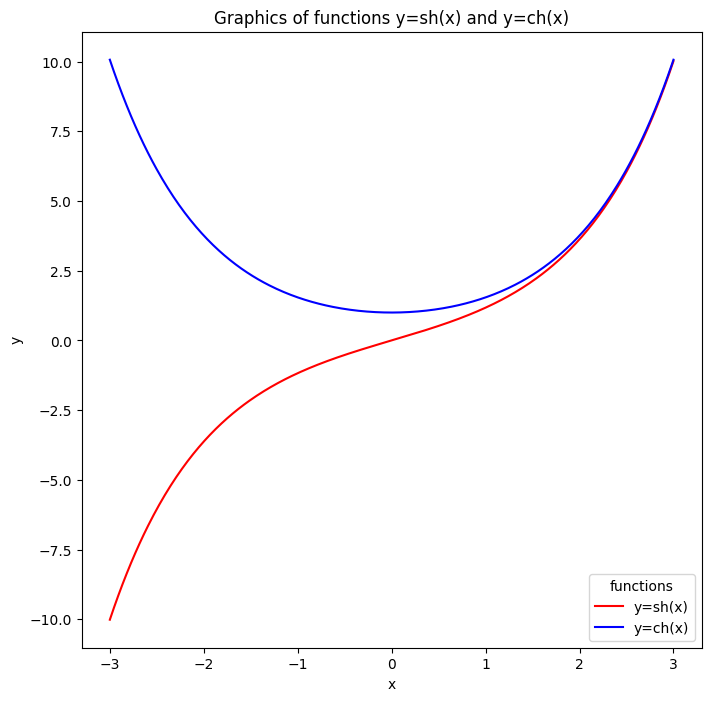

In [18]:
x=np.linspace(-3,3,400)
y1=np.sinh(x)
y2=np.cosh(x)
plt.figure(figsize=(8,8))
plt.plot(x,y1,label='y=sh(x)',color='r')
plt.plot(x,y2,label='y=ch(x)',color='b')
plt.title('Graphics of functions y=sh(x) and y=ch(x)')
plt.xlabel('x')
plt.ylabel('y')
plt.legend(title='functions')# (◕‿◕)♡ your code here

### Задание 6 (0.5 балла)

Ранее мы уже проверили сбалансированность данных по разным категориям активностей в train и test сетах. Теперь визуализируйте количество сэмплов в каждой из категорий отдельно для train и test сетов, как в примере ниже. Проследите, чтобы порядок категорий слева и справа был одинаков. Иначе не очень удобно их сравнивать (когда они в разных местах двух графиков). Также заметьте, что в примере ось Х в одинаковом масштабе, что тоже удобно для сравнения.

Вам может пригодиться:
- plt.barh или ax.barh

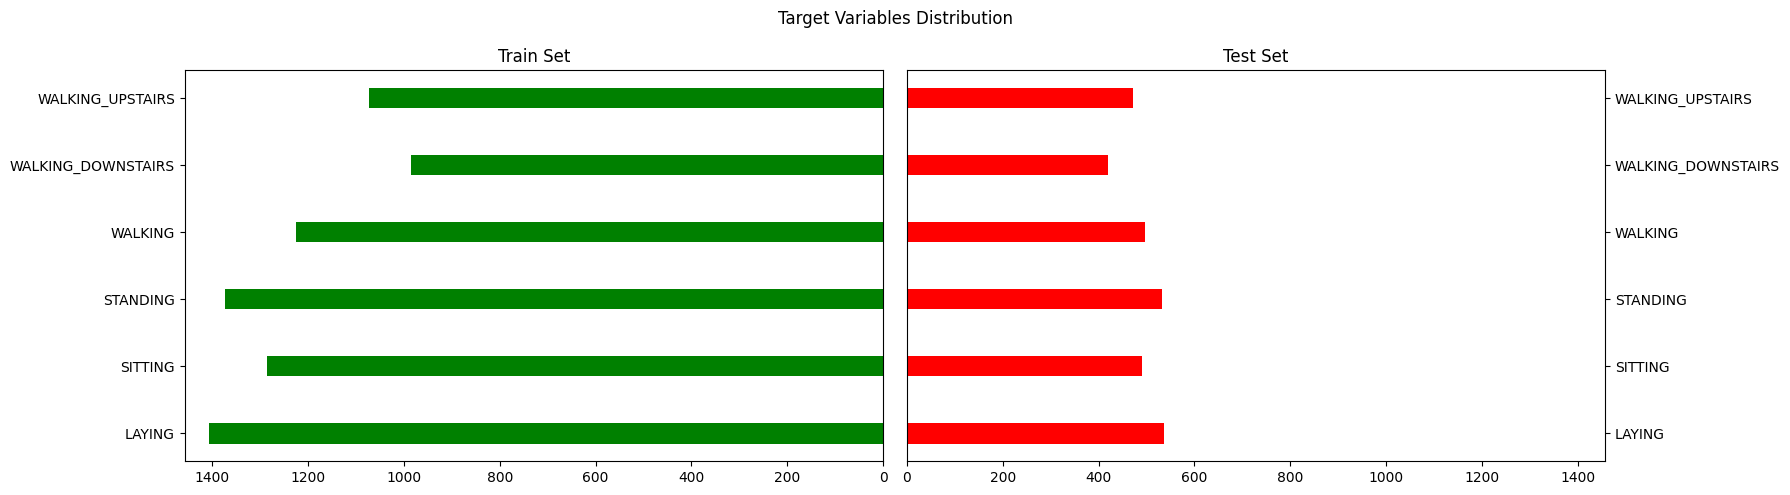

In [19]:
train_count=train['Activity'].value_counts()
test_count=test['Activity'].value_counts()
fig, ax = plt.subplots(1, 2, figsize=(18, 5))
labels = train_count.index.union(test_count.index)

train_count = train_count.reindex(labels, fill_value=0)
test_count = test_count.reindex(labels, fill_value=0)
plt.title('Target variables distribution')
ax[0].barh(labels, train_count, color='green',height=0.3)
ax[0].set_title('Train Set')
ax[0].set_xlim(0, max(train_count.max(), test_count.max()) + 50)

ax[1].barh(labels, test_count, color='red',height=0.3)
ax[1].set_title('Test Set')
ax[1].set_xlim(0, max(train_count.max(), test_count.max()) + 50)
ax[0].invert_xaxis()
ax[1].yaxis.tick_right()
fig.suptitle('Target Variables Distribution')
plt.tight_layout()
plt.show()


In [20]:
# ̿' ̿'\̵͇̿̿\з=( ͡ °_̯͡° )=ε/̵͇̿̿/'̿'̿ ̿ your code here

Правда на таких графиках проще проверять баланс классов таргета?)

### Задание 7 (0.5 балла)

Ранее вы выводили таблицу корреляций. Однако просто таблица корреляций не очень удобна для анализа. Что, если признаков было бы больше? Визуализируйте heatmap корреляций. Подпишите значения корреляций, округленные до 2 знаков после запятой, на графике и оставьте только те значения, которые по модулю не меньше 0.5. Будем считать такие корреляции существенными. Если будете брать код из семинарского ноутбука, то поменяйте в нем что-нибудь, например, цветовую гамму, иначе проверяющий будет карать :)

Какой признак стоит исключить из рассмотрения корреляций? Напишите его название, а также причину, почему нет смысла его рассматривать.

Вам может пригодиться:
- sns.heatmap
- методы get_text и set_text у атрибута texts графика

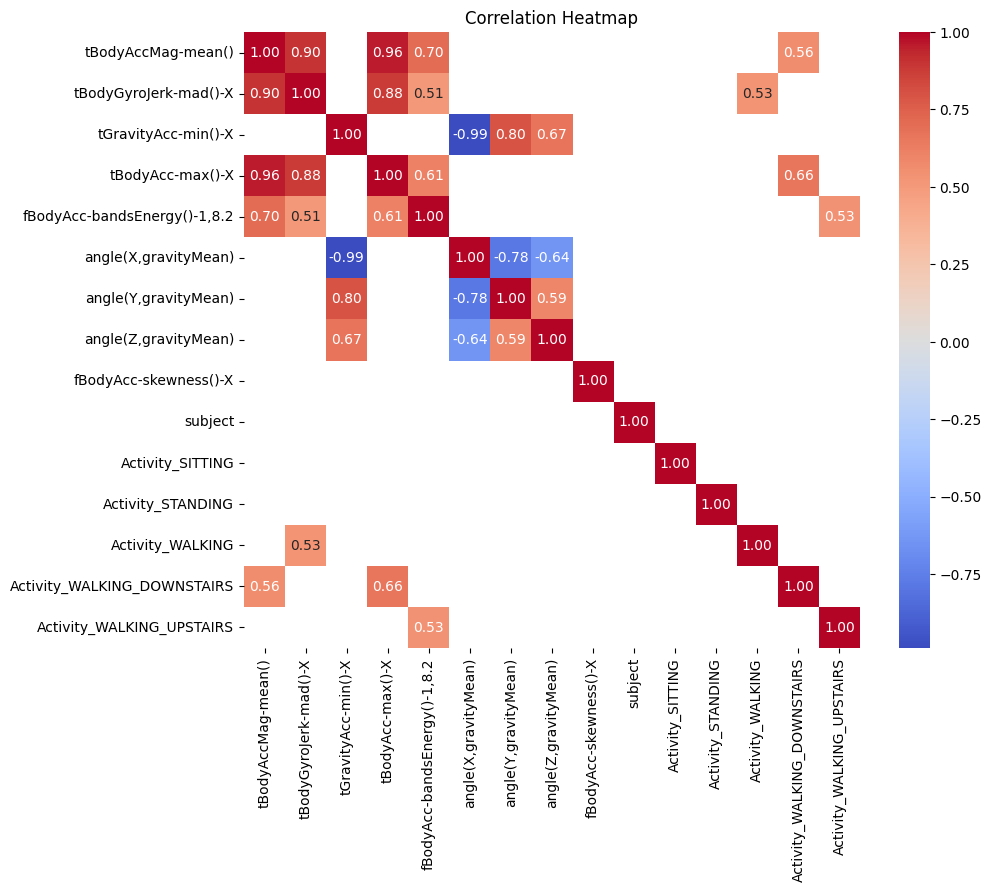

In [21]:
plt.figure(figsize=(10,8))
correlation_matrix=correlation_matrix[correlation_matrix.abs() >= 0.5]
mask = correlation_matrix.isnull()
heatmap = sns.heatmap(correlation_matrix, annot=True, fmt=".2f", mask=mask,cmap='coolwarm', cbar=True, square=True)
for text in heatmap.texts:
    text.set_text(text.get_text())
plt.title('Correlation Heatmap')
plt.show()

Я бы исключила признак с номером испытуемого. Во-первых, по хитмэпу видно, что у него нет сильных зависимостей с другими признаками. А во-вторых, айдишники довольно бессмысленны при обучении модели, ведь они никак не связаны с целевой переменной.

### Задание 8 (0.5 балла)

Для начала будем стрелять из пушки по воробьям. Выведите pairplot по всем данным train сета. Напишите, заметили ли вы в нем что-нибудь интересное, чего не было в таблицах и графиках ранее, а также сообщите, было ли вам удобно анализировать 100 графиков.

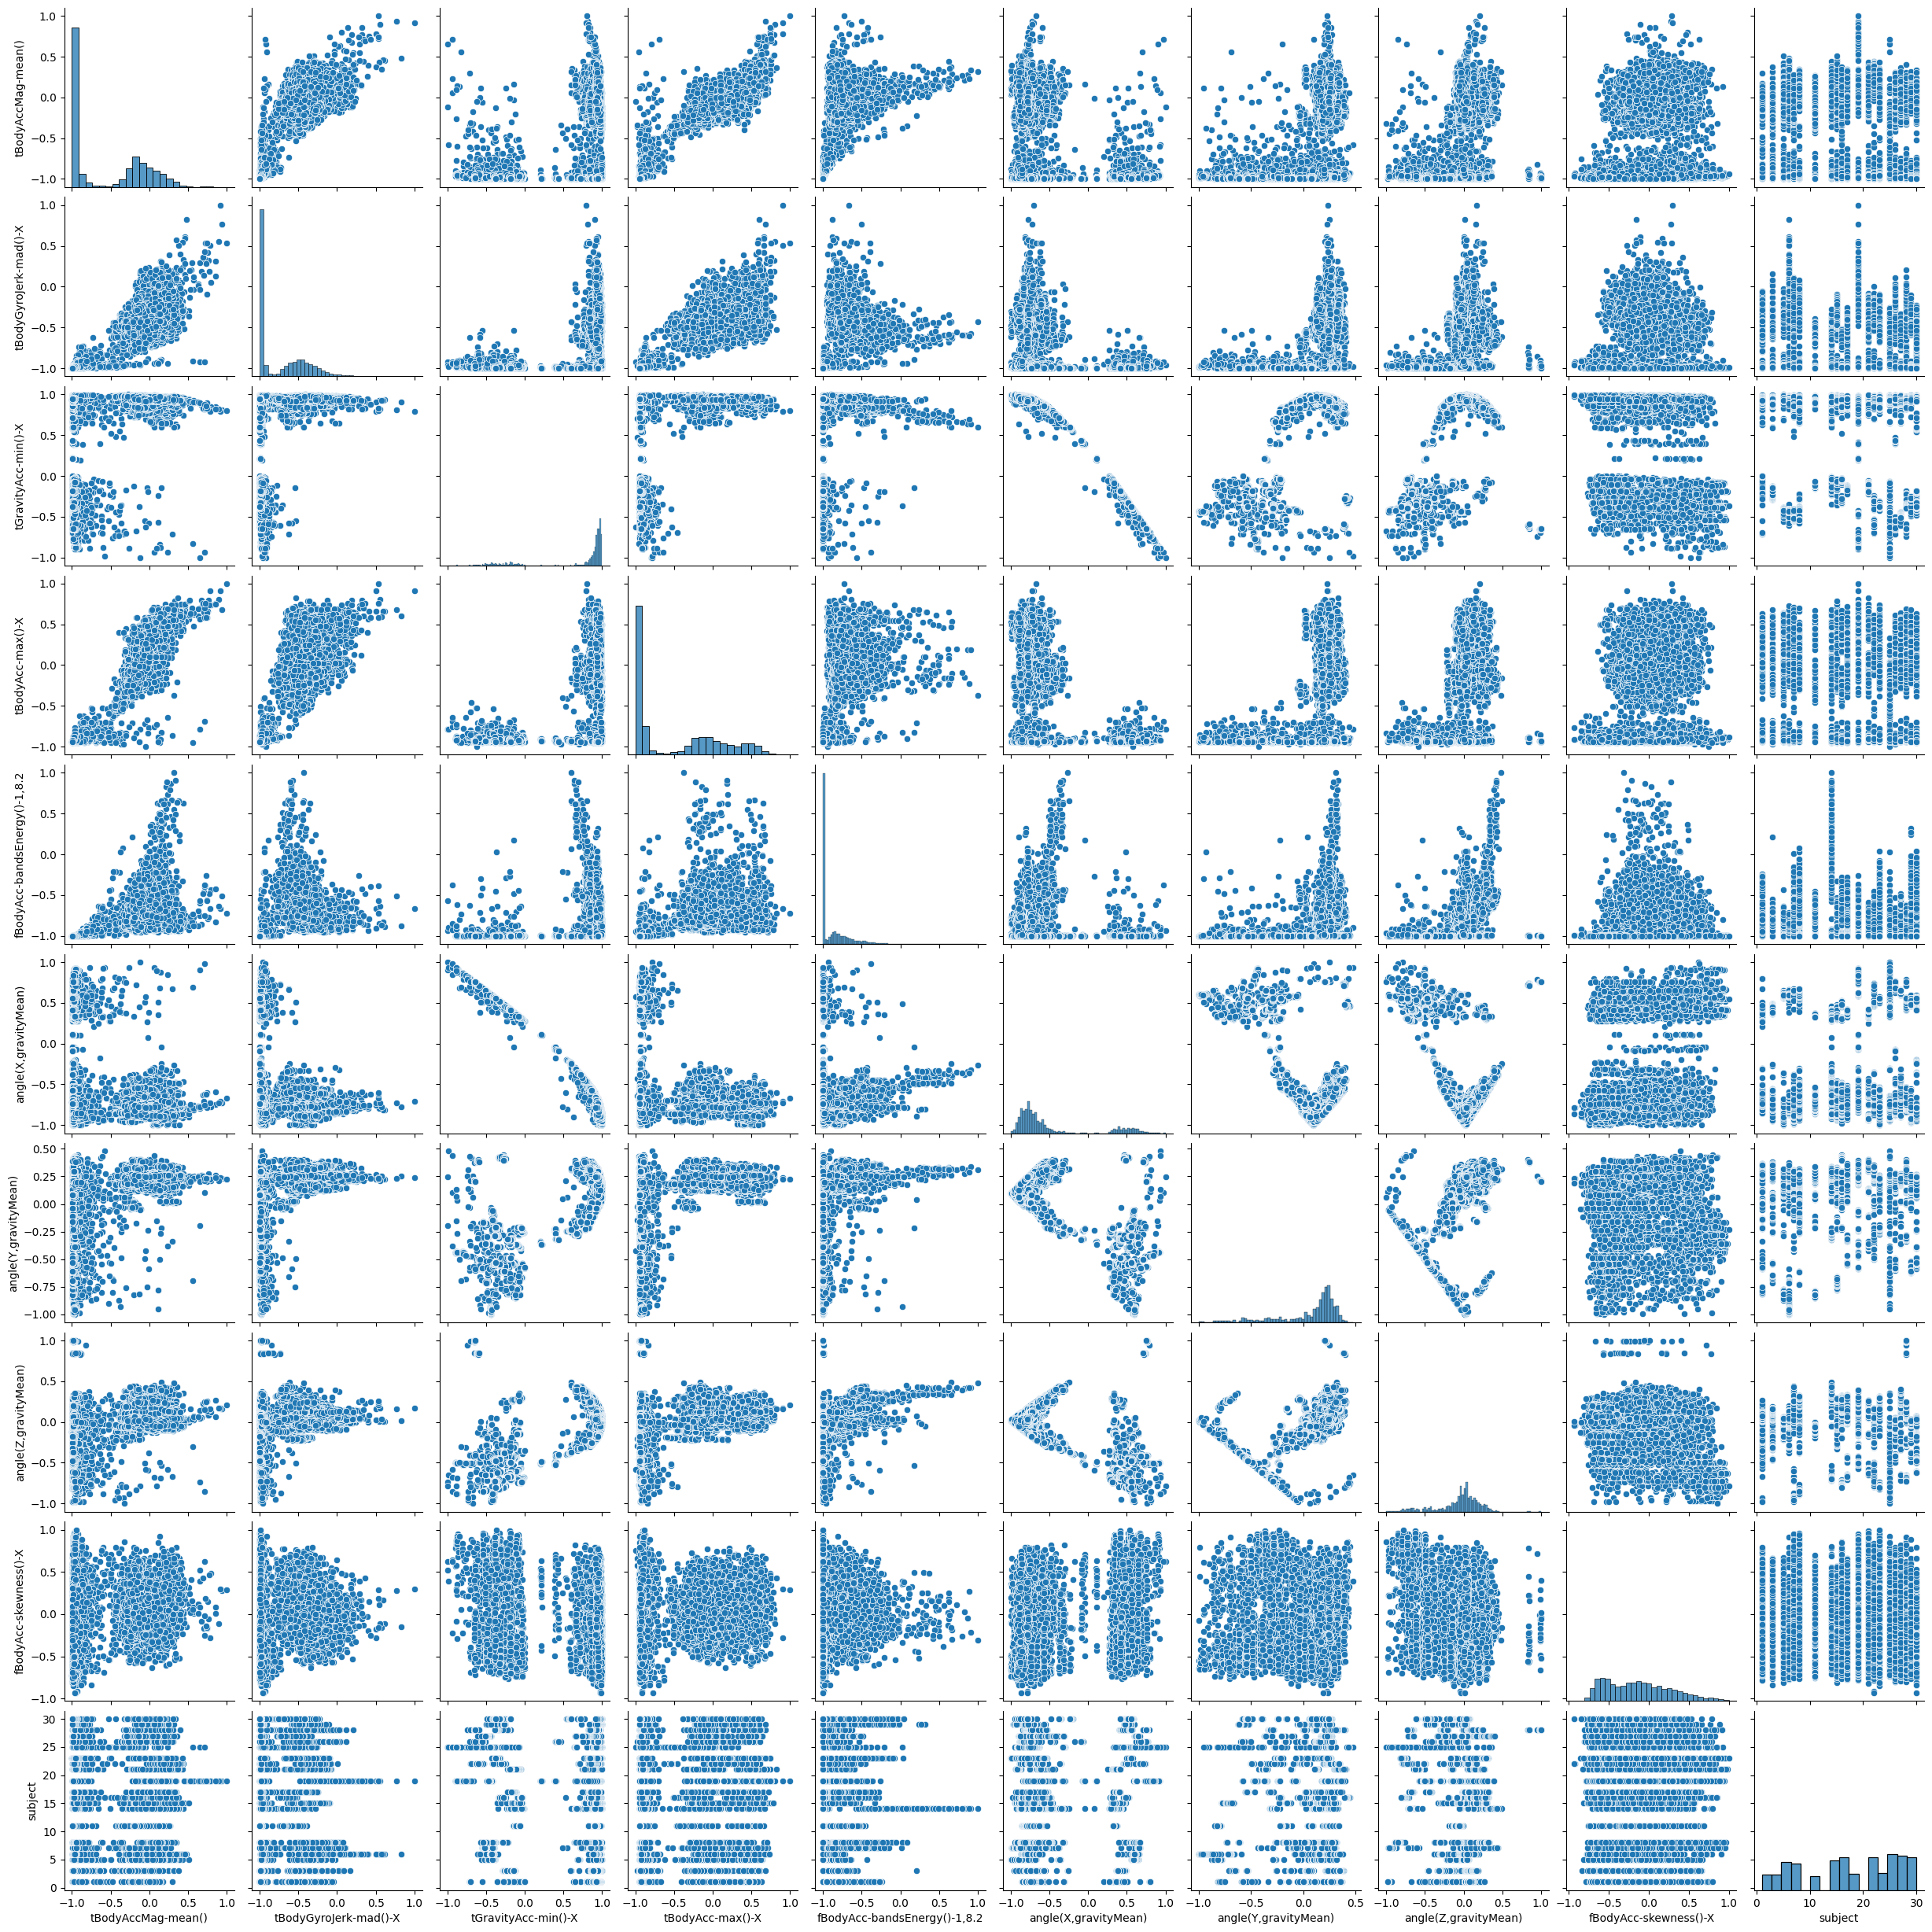

In [22]:
sns.pairplot(train)
plt.show()

На этом графике можно увидеть сильные зависимости признаков (точки находятся на диагонали), однако это видно и из матрицы коррелляций. На диагонали здесь находятся распределения значений признаков, но анализировать столько графиков крайне неудобно.

### Задание 9 (1 балл)

Окей. Смотреть на все сразу не очень удобно. Кажется, нужно смотреть на признаки в отдельности и искать в них инсайты.

Попробуем проверить гипотезу. Отобразите плотность распределения (kde) `tBodyAccMag-mean()` для каждой из активностей, как в примере ниже. Видите закономерность? Можно ли поделить все активности на две группы? Если да, то проведите вертикальную линию, которая визуально неплохо разделяет эти группы.

Давайте первую группу называть статическими активностями, а вторую - динамическими.

Посчитайте, какую долю правильных ответов дает ваша вертикальная линия для разделения именно этих двух групп. С чем может быть связан полученный вами результат? Предположите логическое обоснование (почему именно данный признак так хорошо/плохо разделяет группы активностей).

Вам может пригодиться:
- sns.kdeplot

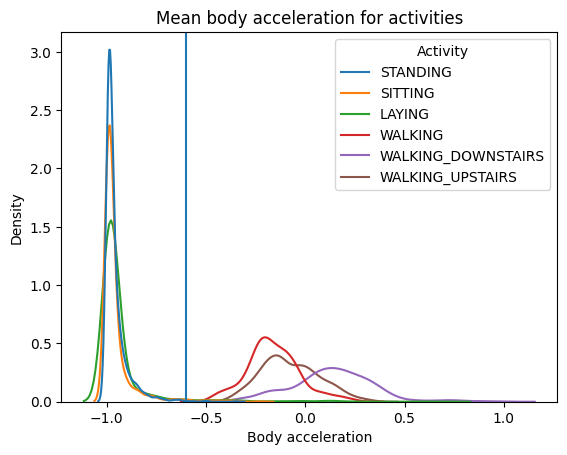

In [23]:
sns.kdeplot(data=train, x='tBodyAccMag-mean()', hue='Activity',legend=True)
plt.axvline(x=-0.6)

plt.title('Mean body acceleration for activities')
plt.xlabel('Body acceleration')
plt.ylabel('Density')
plt.show()
# ʅ(◔౪◔ ) ʃ your code here

На графике видна следующая закономерность: активности, соответствующие зеленой, желтой и синей кривой сначала плотны ( их графики возрастают), а потом их плотность при ускорении больше -0.6 стремится к нулю. С тремя оставшимися графиками ровно наоборот: при ускорении до -0ю6 плотность нулевая, а потом начинает возрастать. Поэтому я предложила бы провести прямую x=-0.6.

Проверим следующую гипотезу: все активности, у которых ускорение тела меньше -0.6 , будут относиться к статическим, а у которых больше -- к динамическим.

In [24]:
train1=train
def type(x):
  if x=='SITTING' or x== 'LAYING' or x== 'STANDING':
    return 0
  else:
    return 1
def f(x):
  if x<=-0.6:
    return 0
  else:
    return 1
train1['category']=train['Activity'].apply(type)
train1['predicted']=train['tBodyAccMag-mean()'].apply(f)
train1['coincided']=(train1['category']==train1['predicted'])
print(train1['coincided'].mean())

0.9895266594124048


### Задание 10 (0.5 балла)

Поздравляем, вы проверили первую гипотезу в процессе EDA. Однако нам бы хотелось уметь не группы разделять, а каждый отдельный вид активности. Попробуйте нарисовать "ящики с усами" для `angle(X,gravityMean)` с разделением по разным видам активности на данных train. Можно ли сделать какой-то вывод по полученной визуализации? Проанализируйте и проинтерпретируйте полученные картинки (если заметили какую-то особенность, может какая-то категория значительно выделяется, то предположите, почему так могло произойти).

Вам может пригодиться:
- sns.boxplot

Text(0, 0.5, 'Angel')

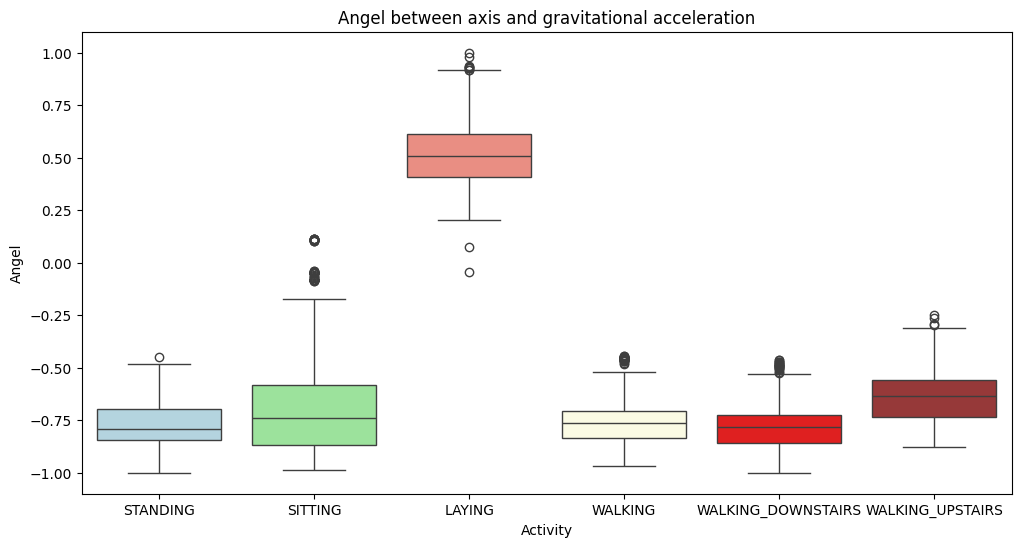

In [25]:
plt.figure(figsize=(12,6))
palette= {'STANDING': 'lightblue', 'SITTING': 'lightgreen', 'LAYING': 'salmon', 'WALKING': 'lightyellow','WALKING_DOWNSTAIRS':'red','WALKING_UPSTAIRS':'brown'}
sns.boxplot(data=train,x='Activity',y='angle(X,gravityMean)',palette=palette)# ^⨀ᴥ⨀^ your code here
plt.title('Angel between axis and gravitational acceleration')
plt.xlabel('Activity')
plt.ylabel('Angel')

Мне кажется очевидным выделение активности лежать -- в больштнстве случаев ее угол больше 0.25, в то время как у остальных он зачастую меньше (он находится между -1 и 0). Такое могло произойти, так когда человек лежит, то он находится в горизонтальом положении, а когда стоит/сидит/идет в вертикальном.

### Задание 11 (0.5 балла)

Посмотрим теперь на `tBodyAcc-max()-X`. Визуализируйте скрипичные диаграммы для этого признака с разделением по активностям на всем train. Кажется логичным, что максимальное ускорение в моменте для разных активностей будет различаться. Однако есть ли активность, которая будет выделяться? Если да, то предложите объяснение, почему эта активность выделяется.

Вам может пригодиться:
- sns.violinplot

Text(0, 0.5, 'Maximal acceleration')

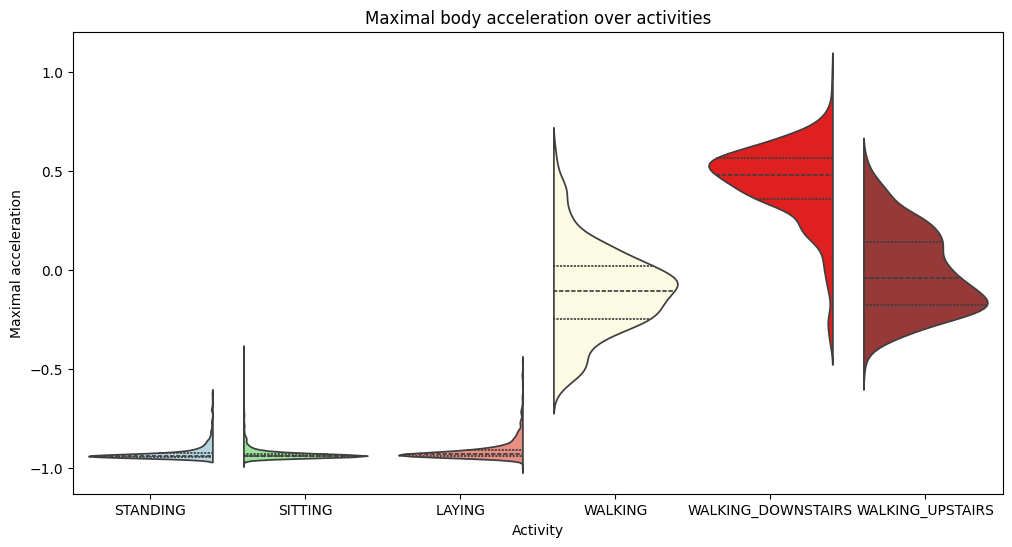

In [26]:
plt.figure(figsize=(12,6))
plt.title('Maximal body acceleration over activities')
sns.violinplot(data=train, x='Activity', y='tBodyAcc-max()-X', inner='quartile',palette=palette,split=True)
plt.xlabel('Activity')
plt.ylabel('Maximal acceleration')
# ( ͡☉ ͜ʖ ͡☉) your code here

На данном графике видно, как сильно различается максимальное ускорение для статических и динамических активностей. Это объяснимо тем, что когда человек не двигается, то и ускорение будет отрицательным. Среди динамических активностей сильно выделяется хождение вниз -- там максимальное ускорение больше. Мне кажется это потому, что человеку идти вниз значительно легче и он ускоряется.

### Задание 12 (1 балл)

Вы уже можете с довольно хорошим качеством выделить две категории активности из шести. Продолжим.

Ранее уже упоминалось разделение на две группы активностей: статические и динамические. Пришла пора разделить датасет train на две части. Сделайте это! Теперь на одной картинке покажите распределения `fBodyAcc-bandsEnergy()-1,8.2` для динамичных активностей (`boxenplot` - немного измененый "ящик с усами") и `angle(Y,gravityMean)` для статических - тут хватит и простой гистограммы (прямо, как в примере ниже). Можно ли выделить еще какие-то активности? Если да, напишите, какие активности на 1 и 2 графиках выделяются.

Вам может пригодиться:
- plt.subplots или matplotlib.gridspec (заметили, что один график больше другого? попробуйте сами так сделать - вам понравится...)
- sns.boxenplot
- sns.histplot

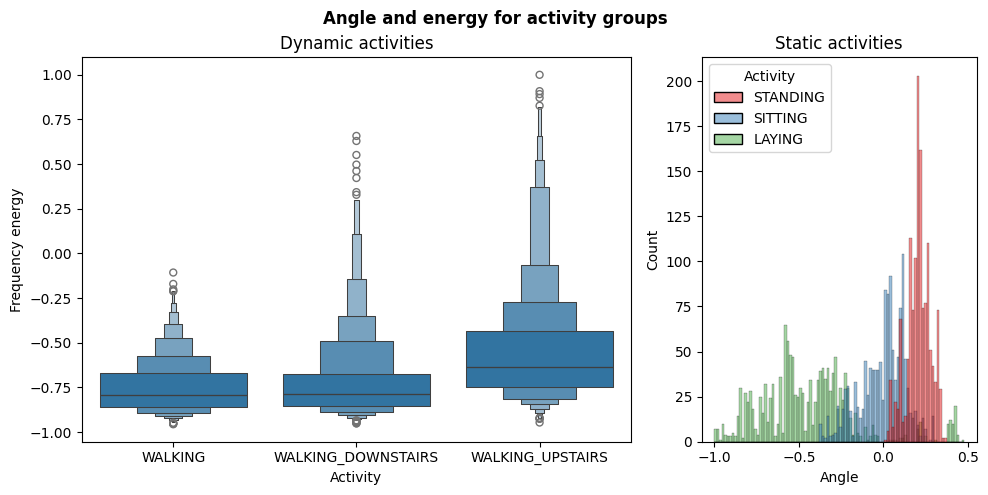

In [27]:
dynamic=['WALKING','WALKING_DOWNSTAIRS','WALKING_UPSTAIRS']
static=['STANDING','SITTING', 'LAYING']
palette_static={'STANDING':'red','SITTING':'salmon','LAYING':'blue'}
train_dynamic=train[train['Activity'].isin(dynamic)]
train_static=train[train['Activity'].isin(static)]
fig, axs=plt.subplots(1,2,figsize=(10,5),gridspec_kw={'width_ratios': [2, 1]})
sns.boxenplot(data=train_dynamic,x='Activity',y='fBodyAcc-bandsEnergy()-1,8.2',ax=axs[0])
axs[0].set_ylabel('Frequency energy')
axs[0].set_title('Dynamic activities')

sns.histplot(data=train_static,x='angle(Y,gravityMean)',bins=100,ax=axs[1],hue='Activity',palette='Set1')
axs[1].set_xlabel('Angle')
axs[1].set_ylabel('Count')
axs[1].set_title('Static activities')
plt.tight_layout(rect=[0, 0, 1, 0.96])
fig.suptitle('Angle and energy for activity groups',weight='bold')
plt.show()

# ‿( ́ ̵ _-`)‿ your code here

На графике для динамических активностей больше всего выделяется хождение наверх -- энергия ускорения положительна в большинстве случаев при хождении наверх. Среди статических активностей наиболее заметно нахождение в положении стоя -- ей в большинстве случаев соответствует угол больше нуля, в то время как двум оставшимся более характерны отрицательные углы.

### Задание 13 (0.5 балла)

Не всегда жизнь будет такой легкой, а данные будут полностью или почти линейно разделимы в одному признаку (иначе чем бы занимались дата саентисты...). Часто данные вообще ни по одному признаку нельзя адекватно разделить (да и по комбинациям признаков тоже). Давайте попробуем взять не один признак, а целых два!

Рассмотрим только статические активности. Будет снова два графика сразу. На первом графике будет боксплот распределения `fBodyAcc-skewness()-X` по активностям. А на втором попробуем взять не все наблюдения данной группы активностей, а только их часть. Разделимы ли категории по `fBodyAcc-skewness()-X`? А если взять только те строки, где `fBodyAcc-skewness()-X < -0.376`, и теперь вывести боксплот распределения `angle(Y,gravityMean)` по разным активностям? Попробуйте и напишите, выделилась ли какая-то категория?

Вам может пригодиться:
- plt.subplots или matplotlib.gridspec
- sns.boxplot

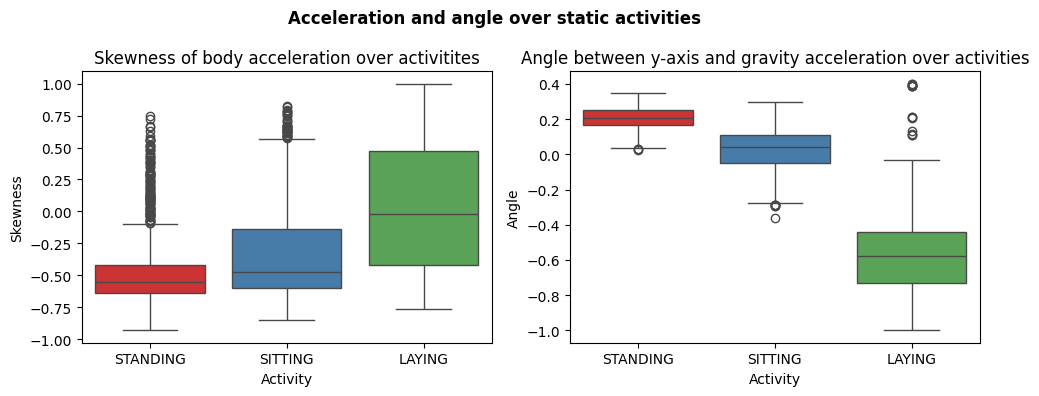

In [28]:
fig,axs=plt.subplots(1,2,figsize=(10,4))
sns.boxplot(data=train_static,x='Activity',y='fBodyAcc-skewness()-X',palette='Set1',ax=axs[0])
axs[0].set_ylabel('Skewness')
axs[0].set_title('Skewness of body acceleration over activitites')
sns.boxplot(data=train_static[train_static['fBodyAcc-skewness()-X'] < -0.376],x='Activity', y='angle(Y,gravityMean)', palette='Set1', ax=axs[1])
axs[1].set_ylabel('Angle')
axs[1].set_title('Angle between y-axis and gravity acceleration over activities')
plt.suptitle('Acceleration and angle over static activities',weight='bold')
plt.tight_layout()
plt.show()
# (ಠ_ಠ) your code here

Мне кажется, что активности не особо заметно разделены по fBodyAcc-skewness()-X. Однако если установить верхнюю грань в -0,376, то активности уже можно разделить: если угол больше 0.1, то, скорее всего это положение стоя, если от -0.1 до 0.1, то положение сидя, а если меньше, то положение лежа.

Поздравляем, теперь вы на шажок ближе к тому, чтобы стать решающим деревом!

### Задание 14 (1 балл)

Вот и осталась лишь одна активность, которую мы никак не выделили. Попробуем и ее какими-то порогами отделить от всех остальных. Да, можно было бы сказать, что, раз уж мы выделили 5 из 6 категорий, то все остальное - это и есть последняя категория, но мы не идем легкими путями. Выделить оставшуюсь категорию с хорошим качеством не так уж и просто. Из доступных признаков, сначала посмотрите на распределение `tBodyAcc-max()-X` на динамических активностях (скрипичная диаграмма отлично подойдет).

А теперь спускаем вам порог `tBodyAcc-max()-X < 0.157`. Для таких строк постройте диаграмму рассеяния для признака `tGravityAcc-min()-X`. Да, получается неидеально, но это честная работа. Можно выбрать порог так, чтобы чисто из таблицы с динамическими активностями из строк, где `tBodyAcc-max()-X < 0.157`, выбрать по некоторому порогу для `tGravityAcc-min()-X` строки так, чтобы доля правильных ответов на оставшейся категории была не меньше 83%!

Вам может пригодиться:
- plt.subplots или matplotlib.gridspec
- sns.violinplot
- sns.swarmplot (иногда лучше подходит, чем просто sns.scatterplot)

Обратите внимание, что подписи к осям можно убирать методами plt. Например, если у вас общее название для оси Y для обоих графиков, то можно не подписывать ось Y у второго графика.

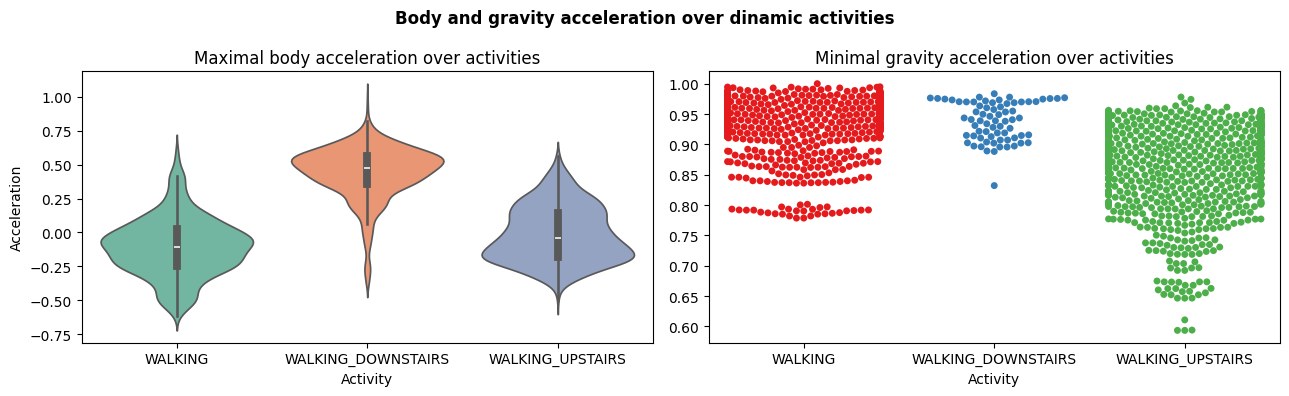

In [29]:
fig,axs=plt.subplots(1,2,figsize=(13,4))
plt.suptitle('Body and gravity acceleration over dinamic activities',weight='bold')
sns.violinplot(data=train_dynamic,x='Activity',y='tBodyAcc-max()-X',palette='Set2',ax=axs[0])
axs[0].set_ylabel('Acceleration')
axs[0].set_title('Maximal body acceleration over activities')

sns.swarmplot(data=train_dynamic[train_dynamic['tBodyAcc-max()-X']<0.157], x='Activity', y='tGravityAcc-min()-X', ax=axs[1],palette='Set1')
axs[1].set_title('Minimal gravity acceleration over activities')
axs[1].set_ylabel('')
plt.tight_layout()
plt.show()

### Задание 15 (0.5 балла)

Теперь попробуем более интерактивные графики. Установите библиотеку `plotly` (обычно `pip install plotly` или `conda install plotly`). Синтаксис очень похож на `seaborn`, но вот [документация для plotly.express](https://plotly.com/python-api-reference/plotly.express.html).

Сначала подготовим данные для визуализации. Будем считать t-SNE просто "черным ящиком", который принимает наши данные и проецирует их в двумерное или трехмерное пространство. Возможно, придется немного подождать.

In [30]:
pip install plotly

In [31]:
%%time
from sklearn.manifold import TSNE
tsne = TSNE(random_state=666, n_components=2)
new = tsne.fit_transform(train.drop(['subject', 'Activity'], axis=1))
df_2_comp = pd.concat([
    pd.DataFrame(new, columns=['x', 'y']),
    train['Activity']
], axis=1)

tsne = TSNE(random_state=666, n_components=3)
new = tsne.fit_transform(train.drop(['subject', 'Activity'], axis=1))
df_3_comp = pd.concat([
    pd.DataFrame(new, columns=['x', 'y', 'z']),
    train['Activity']
], axis=1)

CPU times: user 4min 28s, sys: 558 ms, total: 4min 28s
Wall time: 4min 38s


Теперь нарисуйте scatter-график через `plotly.express` для `df_2_comp` с выделением цветами активностей. Красиво получилось? Видны скопления точек одного цвета? Можно разные активности отделить линиями на данном графике?

In [32]:
import plotly.express as px
fig_2d = px.scatter(df_2_comp,x='x', y='y',color='Activity',title='2D Visualization',labels={'Activity': 'Activity'},color_discrete_sequence=px.colors.qualitative.Set1 )

fig_2d.show()# ʅ(◔౪◔ ) ʃ your code here

Очень красиво. Скопления точек можно попробовать разделить линиями: легче всех отделяется laying в левом верхнем углу, также standing с sitting можно разделить линией x=-20. Динамические активности не так явно, но тоже отделяются -- walking_upstairs справа, walking чуть ниже и левее, а хождение вниз слева и повыше.

Мы не отстаем от трендов и тоже можем в 3D. Сейчас и вы научитесь (если еще не умеете). Нарисуйте scatter_3d-график через `plotly.express` для `df_3_comp` с выделением цветами активностей. Повращайте его. Нормально получилось? Есть ли какая-то структура у точек?

In [33]:
fig_3d = px.scatter_3d(df_3_comp, x='x', y='y', z='z',color='Activity',title='3D Visualization',
                       labels={'Activity': 'Activity'},color_discrete_sequence=px.colors.qualitative.Set2 )
fig_3d.update_traces(marker=dict(opacity=0.5))
fig_3d.show()# (✧≖‿ゝ≖) your code here

При вращении графика можно заметить, что активности снова разбились по скоплениям точек.

### Задание 16 (1 балл)

Мы сделали вам fit. Ваша очередь сделать predict. Допишите функцию, которая принимает на вход датафрейм с признаками, а выдает вектор из предсказаний - для каждой строки датафрейма вы определяете, к какому классу принадлежит объект. Рекомендуем сразу записывать из строками, а не кодировать в числа. Дальше фукнция `accuracy_score` выдаст вам долю правильных ответов.

Подсказка: вы уже отделили категории друг от друга по каким-то признакам. Воспользуйтесь этим знанием! Используя только проведенный вами анализ можно спокойно выбить не менее 75% на train и test! Если вы получите меньше 75%, то балл будет снижен. Авторское решение (на основе всех графиков выше) выбивает 81% и 77% на train и test соответственно. [Шпаргалка с готовыми идеями для такой задачи](https://rutube.ru/video/f884aa6ed5f94120b7304506042fe5bb/)

In [34]:
def row_predict(row: pd.Series) -> str:
  if row['tBodyAccMag-mean()']<-0.6:
      if row['angle(X,gravityMean)']>0.2:
        return 'LAYING'
      if row['fBodyAcc-skewness()-X']<-0.376 and row['angle(Y,gravityMean)']<0.1:
        return 'SITTING'
      if row['angle(Y,gravityMean)']>0:
        return 'STANDING'
      else:
        return 'SITTING'
  else:
      if row['tBodyAcc-max()-X']>0.25:
        return 'WALKING_DOWNSTAIRS'
      if row['fBodyAcc-bandsEnergy()-1,8.2']>-0.75:
        return 'WALKING_UPSTAIRS'
      else:
        return 'WALKING'
def predict(df: pd.DataFrame):
  a=[]
  for _,row in df.iterrows():
    a.append(row_predict(row))
  return a
  pass

def accuracy_score(y_true, y_pred) -> float:
    y_true = np.asarray(y_true).reshape(-1, 1)
    y_pred = np.asarray(y_pred).reshape(-1, 1)
    return (y_true == y_pred).mean()

In [35]:
train_preds = predict(train)
test_preds = predict(test)
print(f"Accuracy on train set => {accuracy_score(train['Activity'], train_preds)}")
print(f"Accuracy on test set => {accuracy_score(test['Activity'], test_preds)}")

Accuracy on train set => 0.7757072905331882
Accuracy on test set => 0.7624703087885986


На тестовой выборке получили больше 0.75, значит цель достигнута.

__Место для мема и/или фидбэка__

> тут